In [108]:
import numpy as np
import RockSat_json.RockSat_json as RockSat_json
import Fitting.RockSat_1_14_fitting_functions as R_fitting
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 22})

Load data, create arrays for composite IV plot and composite number density and temperature plots.  

In [109]:
data = f'UDIP4/data/UDIP_4_800s.json'
figs = 'UDIP4/figs/'

In [110]:
sweep = 100
# V = np.array(packets['packets']['Full'][f'{sweep}']['Voltage'][6:]) 
# I = -np.array(packets['packets']['Full'][f'{sweep}']['Current0'][6:]) * 1e9
packets = RockSat_json.import_data(data)
print(packets['packets'].keys())
print(packets['packets']['Dense'][f'{sweep}'].keys())
# len(packets['packets']['Dense'].keys())
# packets['packets']['Full'][f'{sweep}']['Start']/1000

dict_keys(['Sensor', 'Full', 'Dense'])
dict_keys(['Start', 'Stop', 'Count', 'GroundType', 'Voltage', 'Current0', 'Current1', 'Current2', 'PhotoDiodeInitial', 'PhotoDiodeFinal'])


In [111]:
fsw1 = 202; fsw2 = 208
dsw1 = 22; dsw2 = 23
D = 'Dense'
F = 'Full'
ft1 = packets['packets']['Full'][f'{fsw1}']['Start']
ft2 = packets['packets']['Full'][f'{fsw2}']['Stop']

dt1 = packets['packets']['Dense'][f'{dsw1}']['Start']
dt2 = packets['packets']['Dense'][f'{dsw2}']['Stop']

fGT1 = packets['packets']['Full'][f'{fsw1}']['GroundType']
fGT2 = packets['packets']['Full'][f'{fsw2}']['GroundType']
dGT1 = packets['packets'][D][f'{dsw1}']['GroundType']
dGT2 = packets['packets'][D][f'{dsw2}']['GroundType']
print(ft1,ft2)
print(dt1,dt2)

print(fGT1,fGT2)
print(dGT1,dGT2)

185617 188489
183908 187449
0 1
0 1


/Users/joshuagoodwill/Library/CloudStorage/GoogleDrive-goodwill@udel.edu/My Drive/DAPPEr/Fitting/RockSat_1_14_fitting_functions.py:44: RuntimeWarning: invalid value encountered in sqrt
  return I0 * np.sqrt(1. + k*(x + V0))
/Users/joshuagoodwill/Library/CloudStorage/GoogleDrive-goodwill@udel.edu/My Drive/DAPPEr/Fitting/RockSat_1_14_fitting_functions.py:44: RuntimeWarning: invalid value encountered in sqrt
  return I0 * np.sqrt(1. + k*(x + V0))


2.872


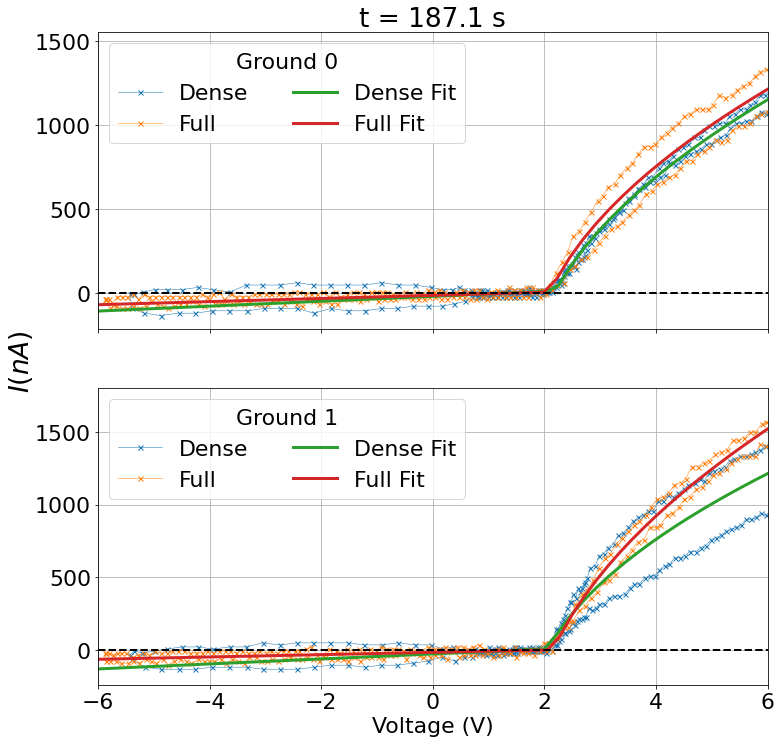

In [112]:

fig, ax = plt.subplots(2,1, figsize = (12, 12), sharex = True)
D = 'Dense'
F = 'Full'
fsw1 = 202; fsw2 = 208
dsw1 = 22; dsw2 = 23
fV1 = np.array(packets['packets'][F][f'{fsw1}']['Voltage'][6:]) 
fI1 = -np.array(packets['packets'][F][f'{fsw1}']['Current0'][6:]) * 1e9
fGT1 = packets['packets']['Full'][f'{fsw1}']['GroundType']
fGT2 = packets['packets']['Full'][f'{fsw2}']['GroundType']

dV1 = np.array(packets['packets'][D][f'{dsw1}']['Voltage'][6:]) 
dI1 = -np.array(packets['packets'][D][f'{dsw1}']['Current0'][6:]) * 1e9
dGT1 = packets['packets'][D][f'{dsw1}']['GroundType']
dGT2 = packets['packets'][D][f'{dsw1}']['GroundType']


ax[0].plot(dV1,dI1, label = D, marker = 'x', markersize = 5, linewidth = 0.5)
ax[0].plot(fV1,fI1, label = F, marker = 'x', markersize = 5, linewidth = 0.5)



t, model, popt, pcov = R_fitting.gen_fit(dV1, dI1)
ax[0].plot(t, model,linewidth = 3, label = D + ' Fit')
t, model, popt, pcov = R_fitting.gen_fit(fV1, fI1)
ax[0].plot(t, model,linewidth = 3, label = F + ' Fit')
ax[0].legend(title = 'Ground 'f'{fGT1}', ncol = 2)


fV2 = np.array(packets['packets'][F][f'{fsw2}']['Voltage'][6:]) 
fI2 = -np.array(packets['packets'][F][f'{fsw2}']['Current0'][6:]) * 1e9

dV2 = np.array(packets['packets'][D][f'{dsw2}']['Voltage'][6:]) 
dI2 = -np.array(packets['packets'][D][f'{dsw2}']['Current0'][6:]) * 1e9




ax[1].plot(dV2,dI2, label = D, marker = 'x', markersize = 5, linewidth = 0.5)
ax[1].plot(fV2,fI2, label = F, marker = 'x', markersize = 5, linewidth = 0.5)
t, model, popt, pcov = R_fitting.gen_fit(dV2, dI2)
ax[1].plot(t, model,linewidth = 3, label = D + ' Fit')
t, model, popt, pcov = R_fitting.gen_fit(fV2, fI2)
ax[1].plot(t, model,linewidth = 3, label = F + ' Fit')

ax[1].legend(title = 'Ground 'f'{fGT2}', ncol = 2)
ax[1].set_xlim(-6, 6)
txt = 30
t1 = packets['packets']['Full'][f'{fsw1}']['Start']
t2 = packets['packets']['Full'][f'{fsw2}']['Stop']
print((t2-t1)/1000)
time = (t1 + t2)/2
fig.supylabel(r'$I (nA)$')
ax[1].set_xlabel('Voltage (V)')
ax[0].set_title('t = 'f'{np.round(time/1000, 1)} s')

ax[0].axhline(0, c = 'black', linewidth = 2,linestyle = '--')
ax[1].axhline(0, c = 'black', linewidth = 2,linestyle = '--')
ax[0].grid()
ax[1].grid()
fig.savefig('UDIP_IV.png')

In [113]:

# fig, ax = plt.subplots(2,1, figsize = (12, 12), sharex = True)
# D = 'Dense'
# F = 'Full'
# sw1 = 21; sw2 = 22
# V = np.array(packets['packets'][D][f'{sw1}']['Voltage'][6:]) 
# I = -np.array(packets['packets'][D][f'{sw1}']['Current0'][6:]) * 1e9
# GT = packets['packets'][D][f'{sw1}']['GroundType']

# t, model, popt, pcov = R_fitting.gen_fit(V, I)

# ax[0].plot(V,I, label = 'Data', marker = 'x')
# ax[0].plot(t, model, label = 'Fit')
# ax[0].legend(title = 'Ground 'f'{GT}')
# #####

# V = np.array(packets['packets'][D][f'{sw2}']['Voltage'][6:]) 
# I = -np.array(packets['packets'][D][f'{sw2}']['Current0'][6:]) * 1e9
# GT = packets['packets'][D][f'{sw2}']['GroundType']
# t, model, popt, pcov = R_fitting.gen_fit(V, I)
# ax[1].plot(V,I, label = 'Data', marker = 'x')
# ax[1].plot(t, model, label = 'Fit')
# ax[1].legend(title = 'Ground 'f'{GT}')
# ax[1].set_xlim(-6, 6)
# txt = 30
# t1 = packets['packets'][D][f'{sw1}']['Start']
# t2 = packets['packets'][D][f'{sw2}']['Stop']
# print((t2-t1)/1000)
# time = (t1 + t2)/2
# fig.supylabel(r'$I (nA)$')
# ax[1].set_xlabel('Voltage (V)')
# ax[0].set_title('Dense Sweep; t = 'f'{np.round(time/1000, 1)} s')

# ax[0].axhline(0, c = 'red', linestyle = '--')
# ax[1].axhline(0, c = 'red', linestyle = '--')
# ax[0].grid()
# ax[1].grid()
# fig.savefig(figs + 'UDIP_IV.png')

In [114]:
packets = RockSat_json.import_data(data)
ne = np.array([])
Te = np.array([])
Imax = np.array([])
t_lin = np.array([])
starting_sweep = 0
stopping_sweep = 450
step           = 1
for sweep in range(starting_sweep, stopping_sweep, step):
    V = np.array(packets['packets']['Full'][f'{sweep}']['Voltage'][6:]) 
    I = -np.array(packets['packets']['Full'][f'{sweep}']['Current0'][6:]) * 1e9
    # plt.plot(V,I)
    t, model, popt, pcov = R_fitting.gen_fit(V, I)
    start = packets['packets']['Full'][f'{sweep}']['Start']
    stop  = packets['packets']['Full'][f'{sweep}']['Stop']
    t_lin = np.append(t_lin, (start + stop)/2/1000)
    ne = np.append(ne,popt[3])
    Te = np.append(Te,popt[4])
    Imax = np.append(Imax, np.max(I))

print(np.max(Imax))

/Users/joshuagoodwill/Library/CloudStorage/GoogleDrive-goodwill@udel.edu/My Drive/DAPPEr/Fitting/RockSat_1_14_fitting_functions.py:44: RuntimeWarning: invalid value encountered in sqrt
  return I0 * np.sqrt(1. + k*(x + V0))


4513.196480938422


Create plots

In [115]:
st = packets['packets']['Full']['0']['Start']
fin = packets['packets']['Full'][f'{stopping_sweep}']['Start']
print(st/1000,fin/1000)

107.677 281.159


In [116]:
start = packets['packets']['Sensor'][f'3000']['Start']/1000
print(start)

288.961


In [117]:
avg = np.arange(0, len(ne), 5)
ne_av = np.array([])
Te_av = np.array([])
tav_lin = np.array([])
for i in avg:
  tav_lin = np.append(tav_lin,np.average(t_lin[i:(i+6)]))
  Te_av = np.append(Te_av,np.average(Te[i:(i+6)]))
  ne_av = np.append(ne_av,np.average(ne[i:(i+6)]))

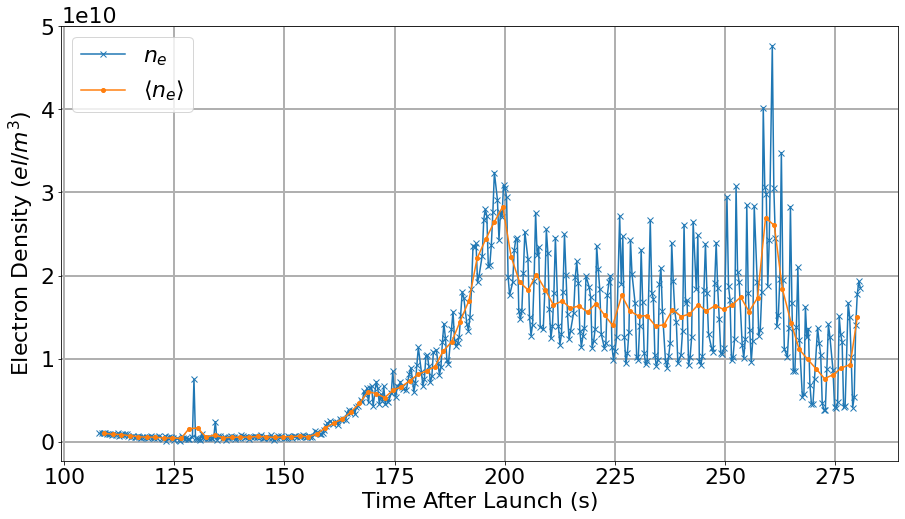

In [118]:
# start = packets['packets']['Full'][f'{starting_sweep}']['Start']/1000
# stop  = packets['packets']['Full'][f'{stopping_sweep}']['Start']/1000
# tav_lin = np.linspace(start, stop, len(ne_av))
fig, ax = plt.subplots(1,1, figsize = (15, 8))
ax.plot(t_lin, ne, marker = 'x', label = r'$n_e$')
ax.plot(tav_lin, ne_av, marker = '.', markersize = 8, label = r'$\langle n_e \rangle$')
ax.legend()
ax.grid(linewidth = 2)
ax.set_xlabel('Time After Launch (s)')
ax.set_ylabel(r'Electron Density $(el/m^3)$')
fig.savefig(figs + 'ne.png')

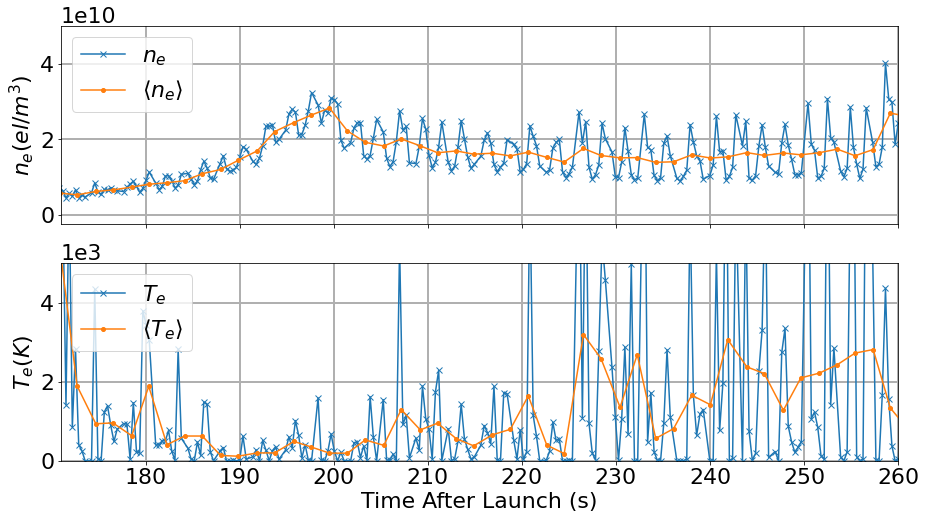

In [119]:
fig, ax = plt.subplots(2,1, figsize = (15, 8), sharex = True)
ax[0].plot(t_lin, ne, marker = 'x', label = r'$n_e$')
ax[0].plot(tav_lin, ne_av, marker = '.', markersize = 8, label = r'$\langle n_e \rangle$')
ax[0].legend()
ax[0].grid(linewidth = 2)
# ax[0].set_xlabel('Time After Launch (s)')
ax[0].set_ylabel(r'$n_e (el/m^3)$')
ax[1].plot(t_lin, Te, marker = 'x', label = r'$T_e$')
ax[1].plot(tav_lin, Te_av, marker = '.', markersize = 8, label = r'$\langle T_e \rangle$')
ax[1].grid(linewidth = 2)
ax[1].set_xlabel('Time After Launch (s)')
ax[1].set_ylabel(r'$T_e (K)$')
ax[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[1].set_ylim(0, 5000)
ax[1].set_xlim(171, 260)
ax[1].legend(loc = 'upper left')
fig.savefig(figs + 'ne_Te.png')